# Reto de Normalización hasta 3FN

**Alumno:** Christopher Meneses Chávez

**Número de control:** 22280295

**Carrera:** Ingeniería en Tecnologías de la Información y Comunicaciones

**Grupo:** 241500

**Fecha:** 09 de septiembre de 2026

**Materia:** Bases de Datos NoSQL

**Profesor:** Federico del Razo López

**Archivo:** `Biblioteca_100000_registros_desnormalizados.csv`


## Objetivo

El archivo de la biblioteca está desnormalizado a propósito. A partir de ese CSV se va a:

1. Explorar los datos e identificar entidades, atributos y dependencias funcionales.
2. Explicar por qué hay redundancia y qué anomalías provoca.
3. Descomponer el modelo hasta 3FN (claves primarias, candidatas y foráneas).
4. Dibujar el diagrama entidad-relación.
5. Crear el esquema con SQL DDL.
6. Transformar e importar los registros de forma reproducible.
7. Validar que no se perdieron préstamos ni asociaciones.
8. Justificar por qué el modelo resultante cumple 3FN.


## 1. Exploración del CSV

Primero se carga el archivo y se revisa cuántas filas trae, qué columnas tiene y si hay nulos. El nombre dice 100,000 registros, hay que comprobarlo.


In [ ]:
import sqlite3
from pathlib import Path

import pandas as pd

csv_path = Path("Biblioteca_100000_registros_desnormalizados.csv")
db_path = Path("biblioteca_3fn.db")

df = pd.read_csv(csv_path)
print("Filas y columnas:", df.shape)
print(list(df.columns))
df.head()


Filas y columnas: (75163, 20)
['prestamo_id', 'fecha_prestamo', 'fecha_devolucion', 'usuario_id', 'usuario_nombre', 'usuario_correo', 'carrera_id', 'carrera_nombre', 'libro_isbn', 'libro_titulo', 'autor_id', 'autor_nombre', 'editorial_id', 'editorial_nombre', 'categoria_id', 'categoria_nombre', 'ejemplar_id', 'ubicacion', 'bibliotecario_id', 'bibliotecario_nombre']


,prestamo_id,fecha_prestamo,fecha_devolucion,usuario_id,usuario_nombre,usuario_correo,carrera_id,carrera_nombre,libro_isbn,libro_titulo,autor_id,autor_nombre,editorial_id,editorial_nombre,categoria_id,categoria_nombre,ejemplar_id,ubicacion,bibliotecario_id,bibliotecario_nombre
0,P0000001,2025-10-12,2025-11-05,U00831,Eduardo Cruz Ramírez,u00831@alumno.edu.mx,CAR08,Ingeniería en Logística,978-7-5300-0530-0,Programación con Python,AUT0015,Andrea Jiménez Pérez,ED01,Pearson,CAT06,Física,EJ002084,P2-B01,BIB018,Lucía González López
1,P0000002,2026-05-18,2026-06-01,U00517,Elena Díaz Castillo,u00517@alumno.edu.mx,CAR06,Ingeniería Electrónica,978-8-1373-0739-6,Métodos de Python,AUT0231,Mónica Díaz Rodríguez,ED04,Springer,CAT02,Programación,EJ002936,P2-B01,BIB008,Carlos Morales Jiménez
2,P0000003,2024-07-24,2024-08-19,U01050,Miguel Gómez Pérez,u01050@alumno.edu.mx,CAR08,Ingeniería en Logística,978-8-1208-0635-5,Fundamentos de Computación en la Nube,AUT0255,Elena Rodríguez Martínez,ED03,Alfaomega,CAT07,Electrónica,EJ002504,PB-A02,BIB010,Roberto Gómez Cruz
3,P0000004,2025-04-17,2025-05-08,U01797,Elena Pérez Jiménez,u01797@alumno.edu.mx,CAR02,Ingeniería en Tecnologías de la Información y ...,978-9-7658-0369-1,Fundamentos de Minería de Datos,AUT0268,Valeria Martínez Rodríguez,ED07,Addison-Wesley,CAT11,Sistemas Operativos,EJ001439,P1-A02,BIB012,Iván López Martínez
4,P0000005,2026-07-26,2026-08-01,U00202,Natalia Castillo Torres,u00202@alumno.edu.mx,CAR05,Ingeniería Química,978-3-9892-0764-0,Diseño de Ingeniería de Software,AUT0016,Diego Torres Morales,ED06,Oxford University Press,CAT01,Bases de Datos,EJ003046,PB-B02,BIB017,Patricia Vázquez Torres


In [ ]:
print("Valores únicos por columna:")
print(df.nunique(dropna=True))
print()
print("Nulos:")
print(df.isna().sum())


Valores únicos por columna:
prestamo_id             75163
fecha_prestamo            951
fecha_devolucion          978
usuario_id               2500
usuario_nombre           2246
usuario_correo           2500
carrera_id                  8
carrera_nombre              8
libro_isbn                800
libro_titulo              121
autor_id                  291
autor_nombre              286
editorial_id               10
editorial_nombre           10
categoria_id               12
categoria_nombre           12
ejemplar_id              3176
ubicacion                  10
bibliotecario_id           20
bibliotecario_nombre       20
dtype: int64

Nulos:
prestamo_id                0
fecha_prestamo             0
fecha_devolucion        4524
usuario_id                 0
usuario_nombre             0
usuario_correo             0
carrera_id                 0
carrera_nombre             0
libro_isbn                 0
libro_titulo               0
autor_id                   1
autor_nombre               1
edi

In [ ]:
print("¿prestamo_id es único?", df["prestamo_id"].nunique() == len(df))
print("Préstamos abiertos (sin fecha_devolucion):", df["fecha_devolucion"].isna().sum())

incompletos = df[df["ejemplar_id"].isna()]
print("Filas incompletas (faltan datos del libro/ejemplar):", len(incompletos))
incompletos


¿prestamo_id es único? True
Préstamos abiertos (sin fecha_devolucion): 4524
Filas incompletas (faltan datos del libro/ejemplar): 1


,prestamo_id,fecha_prestamo,fecha_devolucion,usuario_id,usuario_nombre,usuario_correo,carrera_id,carrera_nombre,libro_isbn,libro_titulo,autor_id,autor_nombre,editorial_id,editorial_nombre,categoria_id,categoria_nombre,ejemplar_id,ubicacion,bibliotecario_id,bibliotecario_nombre
75162,P0075163,2025-06-30,2025-07-25,U01414,Daniela Cruz Flores,u01414@alumno.edu.mx,CAR07,Ingeniería Electromecánica,978-2-3747-0441-0,Introducción a Redes de Comput,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


El archivo **no tiene 100,000 registros**. Trae **75,163** filas y la última (`P0075163`) viene cortada: tiene usuario y fechas, pero ya no trae autor, editorial, ejemplar ni bibliotecario. Eso se toma en cuenta al importar; no se inventan datos.

`fecha_devolucion` vacía no es un error: son préstamos que todavía no se devuelven (4,524).


In [ ]:
print("Autores por ISBN:")
print(df.dropna(subset=["autor_id"]).groupby("libro_isbn")["autor_id"].nunique().describe())
print("ISBN con más de un autor:",
      (df.dropna(subset=["autor_id"]).groupby("libro_isbn")["autor_id"].nunique() > 1).sum())

print()
print("Ejemplares por ISBN:")
print(df.dropna(subset=["ejemplar_id"]).groupby("libro_isbn")["ejemplar_id"].nunique().describe())

print()
print("Un ejemplar = un ISBN:",
      (df.dropna(subset=["ejemplar_id"]).groupby("ejemplar_id")["libro_isbn"].nunique() == 1).all())
print("Una ubicación por ejemplar:",
      (df.dropna(subset=["ejemplar_id"]).groupby("ejemplar_id")["ubicacion"].nunique() == 1).all())
print("Una editorial por ISBN:",
      (df.dropna(subset=["editorial_id"]).groupby("libro_isbn")["editorial_id"].nunique() == 1).all())
print("Una categoría por ISBN:",
      (df.dropna(subset=["categoria_id"]).groupby("libro_isbn")["categoria_id"].nunique() == 1).all())
print("Una carrera por usuario:",
      (df.groupby("usuario_id")["carrera_id"].nunique() == 1).all())

print()
print("Usuarios con el mismo nombre (homónimos):",
      (df.groupby("usuario_nombre")["usuario_id"].nunique() > 1).sum())
print("Autores con el mismo nombre:",
      (df.dropna(subset=["autor_nombre"]).groupby("autor_nombre")["autor_id"].nunique() > 1).sum())
print("El correo identifica al usuario:",
      (df.groupby("usuario_correo")["usuario_id"].nunique() == 1).all())


Autores por ISBN:
count    800.000000
mean       1.397500
std        0.622477
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        3.000000
Name: autor_id, dtype: float64
ISBN con más de un autor: 259

Ejemplares por ISBN:
count    800.000000
mean       3.970000
std        1.404124
min        2.000000
25%        3.000000
50%        4.000000
75%        5.000000
max        6.000000
Name: ejemplar_id, dtype: float64

Un ejemplar = un ISBN: True
Una ubicación por ejemplar: True
Una editorial por ISBN: True
Una categoría por ISBN: True
Una carrera por usuario: True

Usuarios con el mismo nombre (homónimos): 229
Autores con el mismo nombre: 5
El correo identifica al usuario: True


### Entidades, atributos y dependencias

Con esos conteos se ve lo siguiente:

- Un **préstamo** es de un **ejemplar**, no del libro. Un ISBN tiene entre 2 y 6 copias.
- Un libro puede tener **varios autores** (259 ISBN tienen 2 o 3). Por eso autor no puede ser un campo de `libro`.
- `ubicacion` (ejemplo: `P2-B01`) es del ejemplar. **No hay entidad biblioteca** en el CSV.
- Sí hay **bibliotecario**: es quien registra el préstamo.
- Hay 229 usuarios homónimos. El nombre no sirve como clave.
- El correo sí es único, entonces es clave candidata de usuario.
- `fecha_devolucion` nula = préstamo abierto. No hace falta guardar un flag extra.

**Dependencias funcionales** (si la tabla ancha se identifica por `prestamo_id`):

- `prestamo_id → fecha_prestamo, fecha_devolucion, usuario_id, ejemplar_id, bibliotecario_id`
- `usuario_id → usuario_nombre, usuario_correo, carrera_id`
- `usuario_correo → usuario_id`
- `carrera_id → carrera_nombre`
- `ejemplar_id → libro_isbn, ubicacion`
- `libro_isbn → libro_titulo, editorial_id, categoria_id`
- `editorial_id → editorial_nombre`
- `categoria_id → categoria_nombre`
- `autor_id → autor_nombre`
- `bibliotecario_id → bibliotecario_nombre`

No existe `libro_isbn → autor_id`, porque un ISBN puede tener varios autores.

### Modelo que había propuesto al inicio y qué se corrigió

Al principio había separado: prestamo, usuario, libro, editorial, autor, categoria, biblioteca, carrera y ejemplar.

Eso está bien en la idea general, pero el CSV obliga a corregir varias cosas:

1. Quitar **biblioteca**. No viene en los datos. `ubicacion` es del ejemplar.
2. Agregar **bibliotecario**.
3. Quitar `autor_id` de `libro` y crear `libro_autor` (relación N:N).
4. Quitar `ejemplar_id` de `libro`. Un libro tiene muchos ejemplares; la FK va de ejemplar hacia libro.
5. No usar `numero_disponible` ni `prestamo_abierto`. No vienen en el archivo. El primero se puede calcular y el segundo se deduce de `fecha_devolucion`.


## 2. Redundancia y anomalías

Todo está en una sola tabla. Cada préstamo copia otra vez el nombre del usuario, su carrera, el título, el autor, la editorial, la categoría, la ubicación y el bibliotecario.

Por eso se ven 75,163 préstamos pero solo 2,500 usuarios, 800 libros y 10 editoriales. El nombre de Pearson, por ejemplo, se escribe miles de veces.

**Actualización.** Si una editorial cambia de nombre hay que editar todas las filas donde aparece. Si se cambia en una sola, el mismo `editorial_id` queda con dos nombres.

**Inserción.** No se puede dar de alta un libro o un bibliotecario si todavía no hay un préstamo, porque el renglón mínimo del archivo es un préstamo.

**Eliminación.** Si se borran los préstamos del último libro de una editorial, también se pierde la editorial.

Al separar catálogos (carrera, editorial, autor, etc.) de los préstamos, cada dato se guarda una vez y se referencia por clave.


## 3. Descomposición hasta 3FN

El archivo plano ya está en **1FN** (valores atómicos) y en **2FN** (la PK es `prestamo_id`, que es simple, así que no hay dependencia parcial).

No está en **3FN** porque hay dependencias transitivas, por ejemplo:

`prestamo_id → usuario_id → usuario_nombre`

`prestamo_id → usuario_id → carrera_id → carrera_nombre`

`prestamo_id → ejemplar_id → libro_isbn → editorial_id → editorial_nombre`

El nombre del usuario o de la editorial no dependen directamente del préstamo, dependen de otra no-llave. Eso viola 3FN.

La idea es sacar cada dependencia a su propia tabla, con la determinante como PK.

| Tabla | PK | Clave candidata | FK |
|---|---|---|---|
| carrera | carrera_id | carrera_nombre | |
| usuario | usuario_id | usuario_correo | carrera_id |
| editorial | editorial_id | editorial_nombre | |
| categoria | categoria_id | categoria_nombre | |
| autor | autor_id | (el nombre se repite) | |
| libro | libro_isbn | | editorial_id, categoria_id |
| libro_autor | libro_isbn + autor_id | | libro_isbn, autor_id |
| ejemplar | ejemplar_id | | libro_isbn |
| bibliotecario | bibliotecario_id | bibliotecario_nombre | |
| prestamo | prestamo_id | | usuario_id, ejemplar_id, bibliotecario_id |

Relaciones:

```
carrera 1 --- N usuario 1 --- N prestamo N --- 1 ejemplar N --- 1 libro
libro N --- 1 editorial
libro N --- 1 categoria
libro N --- N autor          (tabla libro_autor)
prestamo N --- 1 bibliotecario
```


## 4. Diagrama entidad-relación

Un usuario (de una carrera) pide un **ejemplar**. Ese ejemplar es una copia de un libro. El libro lo publica una editorial, pertenece a una categoría y puede tener varios autores (por eso está la tabla puente `libro_autor`). El bibliotecario registra el préstamo. Si `fecha_devolucion` es nula, el préstamo sigue abierto.

Los círculos **1** y **N** son la cardinalidad. **PK** es clave primaria y **FK** es foránea.

![Diagrama ER de la biblioteca en 3FN](er_biblioteca.png)


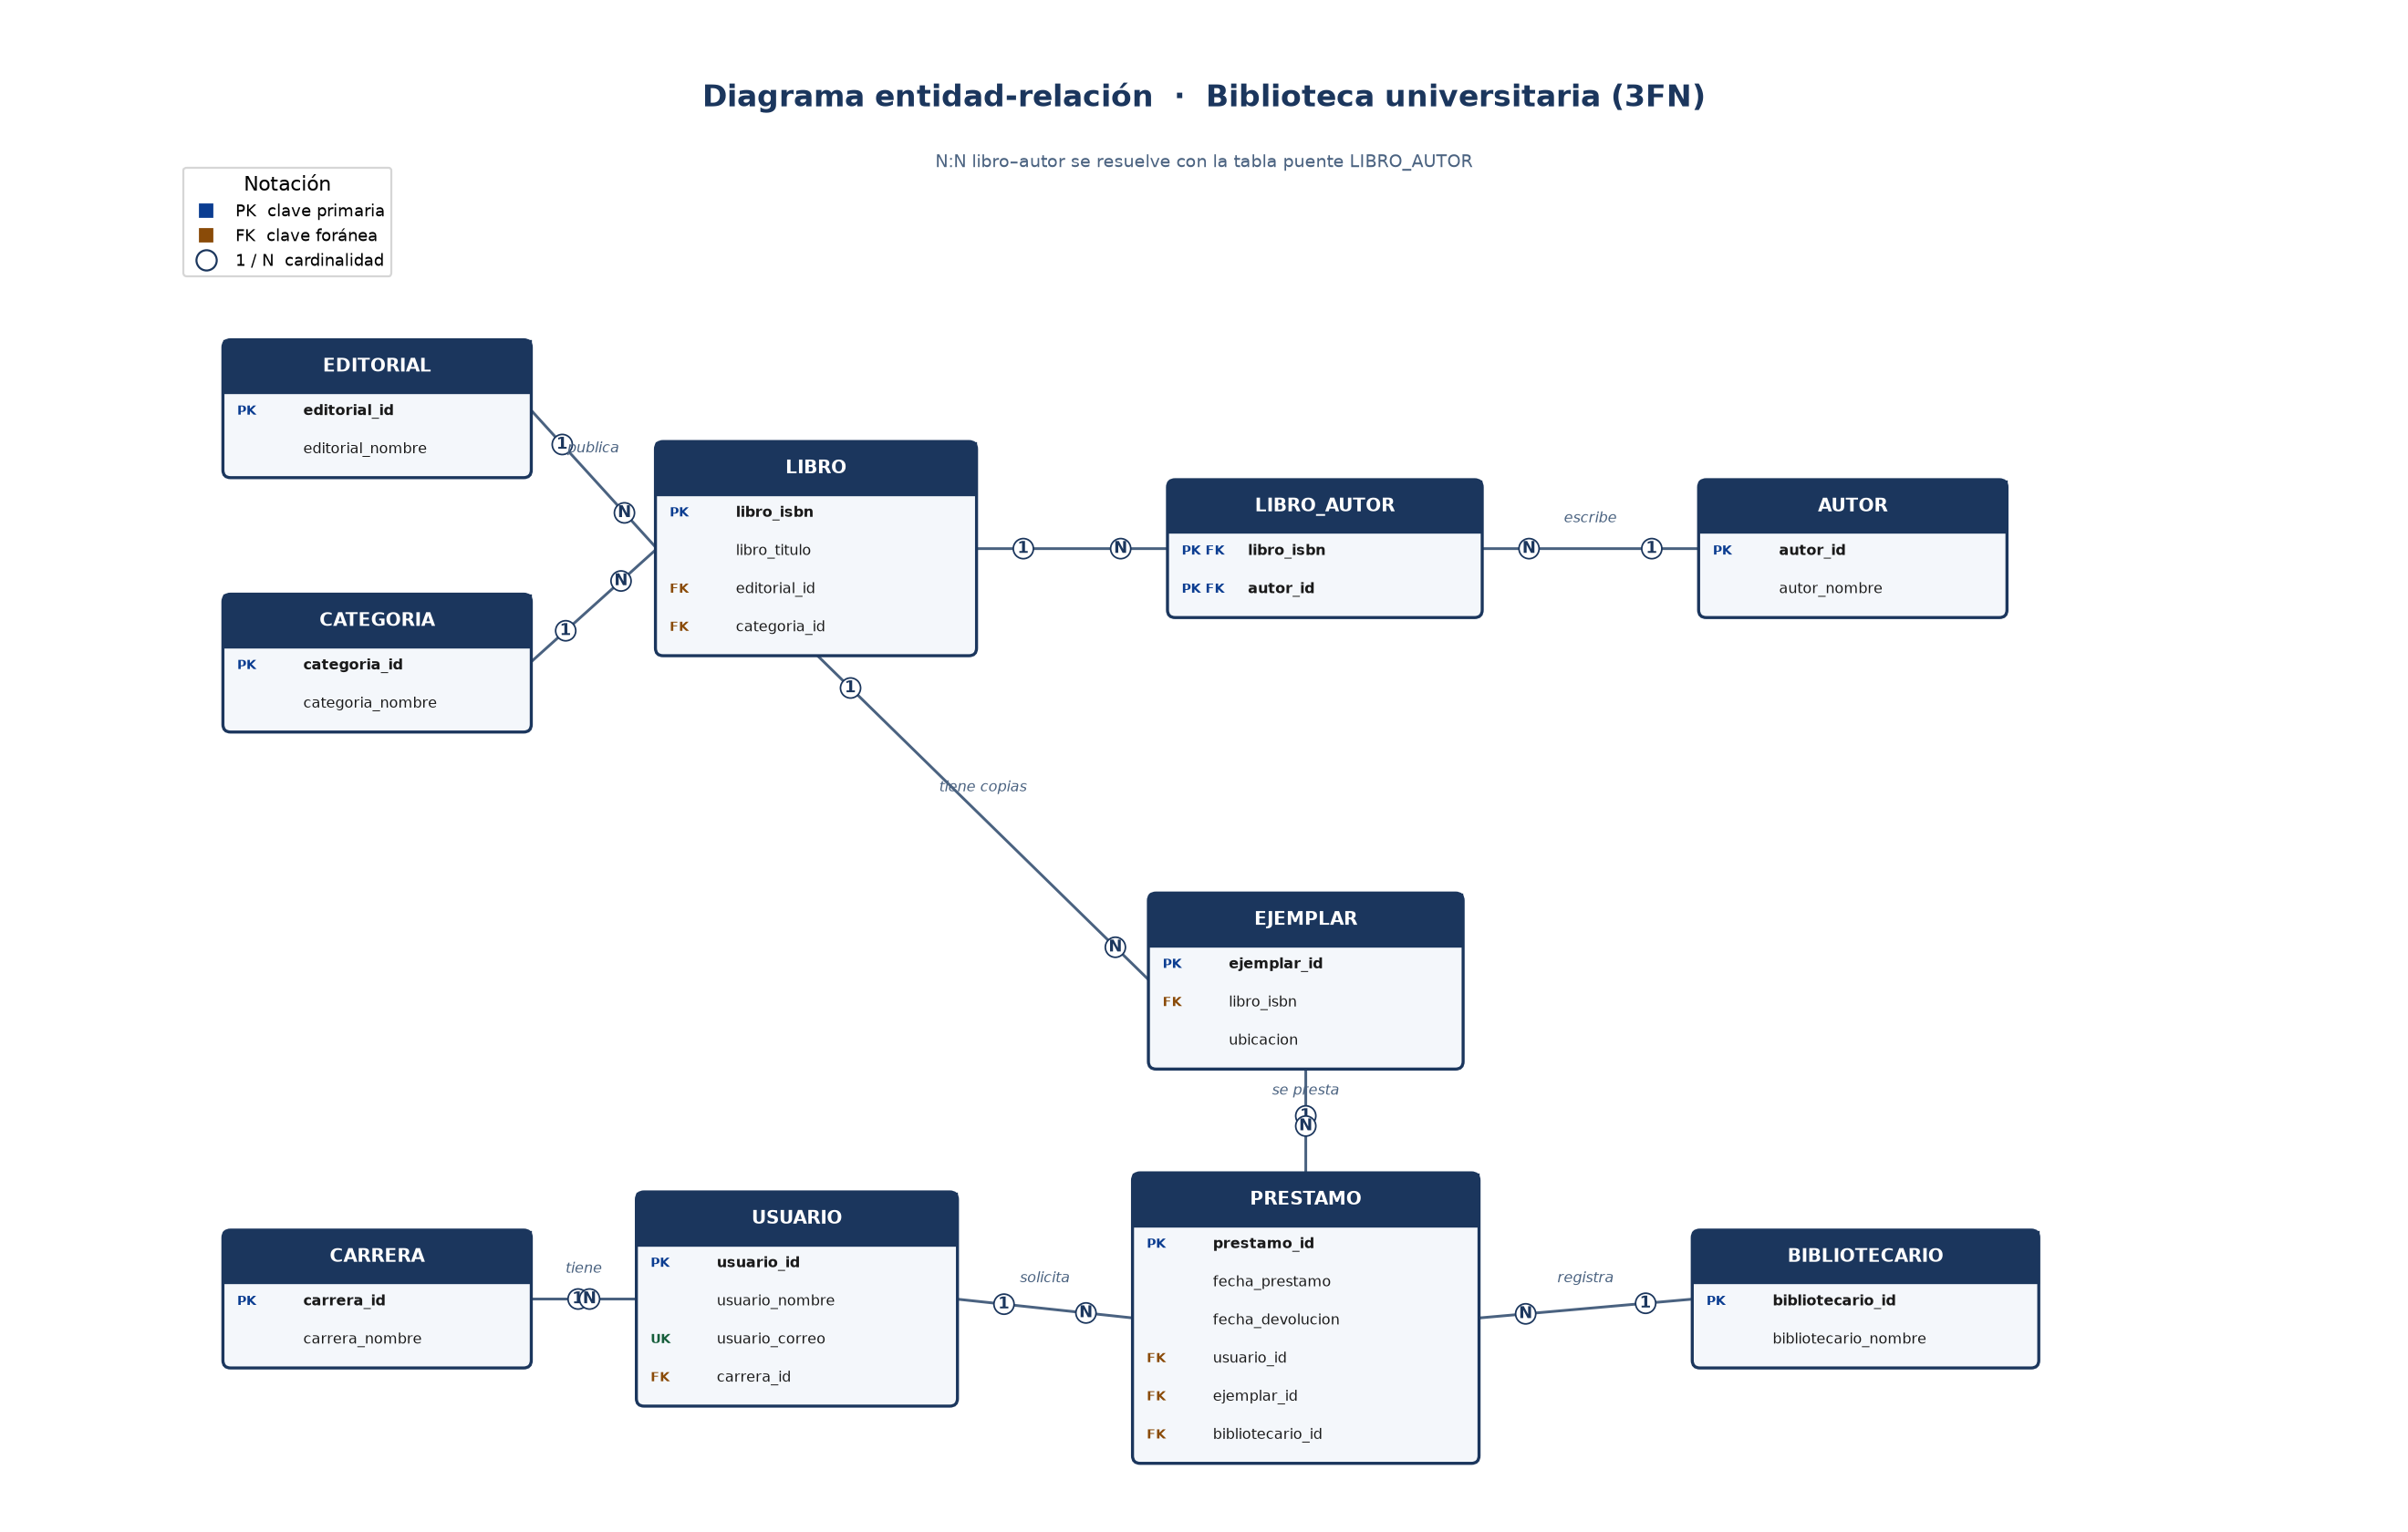

In [ ]:
from IPython.display import Image, display
display(Image("er_biblioteca.png"))


## 5. DDL (SQLite)

Se crea la base en SQLite, igual que en clase. `PRAGMA foreign_keys = ON` es necesario para que las FK sí se validen.


In [ ]:
ddl = '''
PRAGMA foreign_keys = ON;

DROP TABLE IF EXISTS prestamo;
DROP TABLE IF EXISTS ejemplar;
DROP TABLE IF EXISTS libro_autor;
DROP TABLE IF EXISTS libro;
DROP TABLE IF EXISTS bibliotecario;
DROP TABLE IF EXISTS autor;
DROP TABLE IF EXISTS categoria;
DROP TABLE IF EXISTS editorial;
DROP TABLE IF EXISTS usuario;
DROP TABLE IF EXISTS carrera;

CREATE TABLE carrera (
    carrera_id     TEXT PRIMARY KEY,
    carrera_nombre TEXT NOT NULL UNIQUE
);

CREATE TABLE usuario (
    usuario_id     TEXT PRIMARY KEY,
    usuario_nombre TEXT NOT NULL,
    usuario_correo TEXT NOT NULL UNIQUE,
    carrera_id     TEXT NOT NULL,
    FOREIGN KEY (carrera_id) REFERENCES carrera(carrera_id)
);

CREATE TABLE editorial (
    editorial_id     TEXT PRIMARY KEY,
    editorial_nombre TEXT NOT NULL UNIQUE
);

CREATE TABLE categoria (
    categoria_id     TEXT PRIMARY KEY,
    categoria_nombre TEXT NOT NULL UNIQUE
);

CREATE TABLE autor (
    autor_id     TEXT PRIMARY KEY,
    autor_nombre TEXT NOT NULL
);

CREATE TABLE bibliotecario (
    bibliotecario_id     TEXT PRIMARY KEY,
    bibliotecario_nombre TEXT NOT NULL UNIQUE
);

CREATE TABLE libro (
    libro_isbn    TEXT PRIMARY KEY,
    libro_titulo  TEXT NOT NULL,
    editorial_id  TEXT NOT NULL,
    categoria_id  TEXT NOT NULL,
    FOREIGN KEY (editorial_id) REFERENCES editorial(editorial_id),
    FOREIGN KEY (categoria_id) REFERENCES categoria(categoria_id)
);

CREATE TABLE libro_autor (
    libro_isbn TEXT NOT NULL,
    autor_id   TEXT NOT NULL,
    PRIMARY KEY (libro_isbn, autor_id),
    FOREIGN KEY (libro_isbn) REFERENCES libro(libro_isbn),
    FOREIGN KEY (autor_id) REFERENCES autor(autor_id)
);

CREATE TABLE ejemplar (
    ejemplar_id TEXT PRIMARY KEY,
    libro_isbn  TEXT NOT NULL,
    ubicacion   TEXT NOT NULL,
    FOREIGN KEY (libro_isbn) REFERENCES libro(libro_isbn)
);

CREATE TABLE prestamo (
    prestamo_id       TEXT PRIMARY KEY,
    fecha_prestamo    TEXT NOT NULL,
    fecha_devolucion  TEXT,
    usuario_id        TEXT NOT NULL,
    ejemplar_id       TEXT,
    bibliotecario_id  TEXT,
    FOREIGN KEY (usuario_id) REFERENCES usuario(usuario_id),
    FOREIGN KEY (ejemplar_id) REFERENCES ejemplar(ejemplar_id),
    FOREIGN KEY (bibliotecario_id) REFERENCES bibliotecario(bibliotecario_id)
);
'''

if db_path.exists():
    db_path.unlink()

con = sqlite3.connect(db_path)
con.executescript(ddl)
con.commit()
print("Base creada:", db_path.resolve())
print([r[0] for r in con.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name")])


PermissionError: [WinError 32] El proceso no tiene acceso al archivo porque está siendo utilizado por otro proceso: 'biblioteca_3fn.db'

## 6. Transformación e importación

Pasos:

1. Leer el CSV.
2. Separar la fila truncada de las filas completas.
3. Sacar cada catálogo con `drop_duplicates` sobre el id.
4. Armar `libro_autor` con los pares ISBN-autor distintos.
5. Insertar en el mismo orden en que se crearon las tablas.
6. Meter todos los préstamos. En la fila cortada, `ejemplar_id` y `bibliotecario_id` quedan nulos porque el archivo no los trae.


In [ ]:
completos = df.dropna(subset=["ejemplar_id"]).copy()
print("Filas completas:", len(completos))
print("Filas truncadas:", df["ejemplar_id"].isna().sum())


def tabla(origen, cols):
    return origen[cols].dropna().drop_duplicates(subset=cols[0]).copy()


carreras = tabla(df, ["carrera_id", "carrera_nombre"])
usuarios = tabla(df, ["usuario_id", "usuario_nombre", "usuario_correo", "carrera_id"])
editoriales = tabla(completos, ["editorial_id", "editorial_nombre"])
categorias = tabla(completos, ["categoria_id", "categoria_nombre"])
autores = tabla(completos, ["autor_id", "autor_nombre"])
bibliotecarios = tabla(completos, ["bibliotecario_id", "bibliotecario_nombre"])
libros = tabla(completos, ["libro_isbn", "libro_titulo", "editorial_id", "categoria_id"])
libro_autor = completos[["libro_isbn", "autor_id"]].dropna().drop_duplicates().copy()
ejemplares = tabla(completos, ["ejemplar_id", "libro_isbn", "ubicacion"])
prestamos = df[
    ["prestamo_id", "fecha_prestamo", "fecha_devolucion", "usuario_id", "ejemplar_id", "bibliotecario_id"]
].copy()

print("carrera", len(carreras), "usuario", len(usuarios), "editorial", len(editoriales))
print("categoria", len(categorias), "autor", len(autores), "libro", len(libros))
print("libro_autor", len(libro_autor), "ejemplar", len(ejemplares), "bibliotecario", len(bibliotecarios))
print("prestamo", len(prestamos))


Filas completas: 75162
Filas truncadas: 1
carrera 8 usuario 2500 editorial 10
categoria 12 autor 291 libro 800
libro_autor 1118 ejemplar 3176 bibliotecario 20
prestamo 75163


In [ ]:
con.execute("PRAGMA foreign_keys = ON")

for nombre, datos in [
    ("carrera", carreras),
    ("usuario", usuarios),
    ("editorial", editoriales),
    ("categoria", categorias),
    ("autor", autores),
    ("bibliotecario", bibliotecarios),
    ("libro", libros),
    ("libro_autor", libro_autor),
    ("ejemplar", ejemplares),
    ("prestamo", prestamos),
]:
    datos.to_sql(nombre, con, if_exists="append", index=False)
    print(nombre, len(datos))

con.commit()
print("Listo.")


carrera 8
usuario 2500
editorial 10
categoria 12
autor 291
bibliotecario 20
libro 800
libro_autor 1118
ejemplar 3176
prestamo 75163
Listo.


## 7. Validación

Se compara el CSV contra SQLite: mismos conteos, mismos `prestamo_id`, mismos pares libro-autor y ejemplar-ISBN, y que no haya ids duplicados.


In [ ]:
def consultar(sql):
    return pd.read_sql_query(sql, con)

esperados = {
    "carrera": df["carrera_id"].nunique(),
    "usuario": df["usuario_id"].nunique(),
    "editorial": completos["editorial_id"].nunique(),
    "categoria": completos["categoria_id"].nunique(),
    "autor": completos["autor_id"].nunique(),
    "libro": completos["libro_isbn"].nunique(),
    "libro_autor": completos[["libro_isbn", "autor_id"]].dropna().drop_duplicates().shape[0],
    "ejemplar": completos["ejemplar_id"].nunique(),
    "bibliotecario": completos["bibliotecario_id"].nunique(),
    "prestamo": df["prestamo_id"].nunique(),
}

conteos = consultar('''
SELECT 'carrera' AS tabla, COUNT(*) AS n FROM carrera
UNION ALL SELECT 'usuario', COUNT(*) FROM usuario
UNION ALL SELECT 'editorial', COUNT(*) FROM editorial
UNION ALL SELECT 'categoria', COUNT(*) FROM categoria
UNION ALL SELECT 'autor', COUNT(*) FROM autor
UNION ALL SELECT 'libro', COUNT(*) FROM libro
UNION ALL SELECT 'libro_autor', COUNT(*) FROM libro_autor
UNION ALL SELECT 'ejemplar', COUNT(*) FROM ejemplar
UNION ALL SELECT 'bibliotecario', COUNT(*) FROM bibliotecario
UNION ALL SELECT 'prestamo', COUNT(*) FROM prestamo
''')
conteos["csv"] = conteos["tabla"].map(esperados)
conteos["igual"] = conteos["n"] == conteos["csv"]
conteos


,tabla,n,csv,igual
0,carrera,8,8,True
1,usuario,2500,2500,True
2,editorial,10,10,True
3,categoria,12,12,True
4,autor,291,291,True
5,libro,800,800,True
6,libro_autor,1118,1118,True
7,ejemplar,3176,3176,True
8,bibliotecario,20,20,True
9,prestamo,75163,75163,True


In [ ]:
ids_csv = set(df["prestamo_id"])
ids_bd = set(consultar("SELECT prestamo_id FROM prestamo")["prestamo_id"])
print("Préstamos CSV:", len(ids_csv))
print("Préstamos BD:", len(ids_bd))
print("Faltantes:", len(ids_csv - ids_bd))
print("De más:", len(ids_bd - ids_csv))

print()
print("Fila truncada:")
print(consultar("SELECT * FROM prestamo WHERE prestamo_id = 'P0075163'").to_string(index=False))

abiertos_csv = int(df["fecha_devolucion"].isna().sum())
abiertos_bd = int(consultar("SELECT COUNT(*) AS n FROM prestamo WHERE fecha_devolucion IS NULL")["n"].iloc[0])
print("Préstamos abiertos CSV / BD:", abiertos_csv, "/", abiertos_bd)


Préstamos CSV: 75163
Préstamos BD: 75163
Faltantes: 0
De más: 0

Fila truncada:
prestamo_id fecha_prestamo fecha_devolucion usuario_id ejemplar_id bibliotecario_id
   P0075163     2025-06-30       2025-07-25     U01414        None             None
Préstamos abiertos CSV / BD: 4524 / 4524


In [ ]:
pares_csv = set(map(tuple, completos[['libro_isbn', 'autor_id']].dropna().drop_duplicates().values))
pares_bd = set(map(tuple, consultar('SELECT libro_isbn, autor_id FROM libro_autor').values))
print("Pares libro-autor iguales:", pares_csv == pares_bd, len(pares_csv), len(pares_bd))

ej_csv = set(map(tuple, completos[['ejemplar_id', 'libro_isbn']].drop_duplicates().values))
ej_bd = set(map(tuple, consultar('SELECT ejemplar_id, libro_isbn FROM ejemplar').values))
print("Pares ejemplar-ISBN iguales:", ej_csv == ej_bd, len(ej_csv), len(ej_bd))

print("Duplicados de PK:")
for t, pk in [
    ("usuario", "usuario_id"),
    ("libro", "libro_isbn"),
    ("autor", "autor_id"),
    ("ejemplar", "ejemplar_id"),
    ("prestamo", "prestamo_id"),
]:
    d = consultar(f"SELECT COUNT(*) - COUNT(DISTINCT {pk}) AS d FROM {t}")["d"].iloc[0]
    print(" ", t, d)


Pares libro-autor iguales: True 1118 1118
Pares ejemplar-ISBN iguales: True 3176 3176
Duplicados de PK:
  usuario 0
  libro 0
  autor 0
  ejemplar 0
  prestamo 0


In [ ]:
print("Libros con más de un autor:")
print(consultar('''
SELECT l.libro_isbn, l.libro_titulo, COUNT(*) AS n_autores,
       GROUP_CONCAT(a.autor_nombre, ' | ') AS autores
FROM libro l
JOIN libro_autor la ON la.libro_isbn = l.libro_isbn
JOIN autor a ON a.autor_id = la.autor_id
GROUP BY l.libro_isbn
HAVING COUNT(*) > 1
ORDER BY n_autores DESC, l.libro_titulo
LIMIT 8
''').to_string(index=False))

print("\nEjemplares de un mismo ISBN:")
print(consultar('''
SELECT l.libro_isbn, l.libro_titulo, e.ejemplar_id, e.ubicacion
FROM libro l
JOIN ejemplar e ON e.libro_isbn = l.libro_isbn
WHERE l.libro_isbn = (
    SELECT libro_isbn FROM ejemplar GROUP BY libro_isbn HAVING COUNT(*) >= 4 LIMIT 1
)
ORDER BY e.ejemplar_id
''').to_string(index=False))

print("\nPréstamos por carrera:")
print(consultar('''
SELECT c.carrera_nombre, COUNT(*) AS prestamos
FROM prestamo p
JOIN usuario u ON u.usuario_id = p.usuario_id
JOIN carrera c ON c.carrera_id = u.carrera_id
GROUP BY c.carrera_id
ORDER BY prestamos DESC
''').to_string(index=False))


Libros con más de un autor:
       libro_isbn                           libro_titulo  n_autores                                                                 autores
978-1-6002-0252-3           Análisis de Ciencia de Datos          3 Héctor Morales Castillo | Eduardo Mendoza Pérez | Daniela García Flores
978-6-6870-0370-4           Análisis de Ciencia de Datos          3        Daniela López Jiménez | Raúl García Flores | Sergio Reyes Torres
978-6-5634-0166-6     Análisis de Ingeniería de Software          3          María Cruz Pérez | Héctor Cruz Sánchez | Iván Rodríguez Torres
978-0-5492-0124-2           Análisis de Minería de Datos          3           José Vázquez Cruz | Paola Gómez Pérez | Diego Ramírez Jiménez
978-5-8120-0336-0      Análisis de Sistemas Distribuidos          3      Daniela Sánchez Martínez | Raúl López Reyes | Paola Hernández Cruz
978-6-4974-0015-7 Aplicaciones de Aprendizaje Automático          3        Mónica Vázquez Vázquez | Luis Gómez Morales | Ana Gómez M

### Evidencia (CSV vs base)

| Conjunto | CSV | BD |
|---|---:|---:|
| Filas del archivo | 75,163 (no son 100,000; última fila cortada) | |
| préstamos | 75,163 | 75,163 |
| usuarios | 2,500 | 2,500 |
| carreras | 8 | 8 |
| libros (ISBN) | 800 | 800 |
| autores | 291 | 291 |
| libro_autor | 1,118 | 1,118 |
| ejemplares | 3,176 | 3,176 |
| editoriales | 10 | 10 |
| categorías | 12 | 12 |
| bibliotecarios | 20 | 20 |
| préstamos abiertos | 4,524 | 4,524 |


## 8. Por qué el modelo está en 3FN

Cada tabla tiene una PK que determina todos sus atributos y nada más.

No quedó ningún atributo no-llave que determine a otro no-llave:

- En `usuario` el nombre y el correo dependen de `usuario_id`. El nombre de la carrera **no** está ahí; está en `carrera`.
- En `libro` el título, la editorial y la categoría dependen del ISBN. El nombre de la editorial no se guarda en `libro`.
- En `prestamo` solo van las fechas y las FK. El nombre del usuario, el título, el autor, etc. ya no viajan con el préstamo.
- `libro_autor` solo tiene las dos claves de la relación N:N.

Como casi todas las PK son simples, 2FN se cumple. Al quitar las transitivas, también se cumple 3FN.

Eso elimina las anomalías del punto 2: cambiar Pearson es un `UPDATE` de una fila; dar de alta un libro no requiere un préstamo; borrar préstamos no borra la editorial.

### Preguntas de validación

**¿Por qué un autor no se guarda como un solo campo del libro?**  
Porque 259 ISBN tienen más de un autor. Si `autor_id` estuviera en `libro` se perdería un coautor o se duplicaría el libro. Además un autor escribe varios libros. Es N:N.

**¿Qué anomalía se quita al separar Editorial?**  
Sobre todo la de actualización. El nombre se repetía en miles de filas. También la de inserción: ahora sí se puede registrar una editorial sin tener un préstamo.

**¿Cómo se demuestra que no se perdieron préstamos?**  
Los `prestamo_id` del CSV y de la tabla `prestamo` son el mismo conjunto (75,163). Los abiertos también coinciden (4,524).

**¿Qué dependencia justifica una tabla?**  
`carrera_id → carrera_nombre` justifica `carrera`.  
`libro_isbn → libro_titulo, editorial_id, categoria_id` justifica `libro`.  
`ejemplar_id → libro_isbn, ubicacion` justifica `ejemplar`.

### Uso de IA

Se usó Cursor para armar el notebook y las consultas. Lo que se verificó a mano sobre el CSV fue: que no hay 100,000 filas, que la última viene cortada, que libro-autor es N:N, que no existe biblioteca y sí bibliotecario, que `ubicacion` es del ejemplar, y que los conteos CSV vs BD coinciden.


In [ ]:
con.close()
print("Cerrado. Archivo de la base:", db_path.resolve())


Cerrado. Archivo de la base: D:\Universidad\9no Semestre\NSQL\Unidad 1\VSC\Tareas\09-09-26\biblioteca_3fn.db


In [ ]:
import sqlite3
import pandas as pd

con = sqlite3.connect("biblioteca_3fn.db")

def consultar(sql):
    return pd.read_sql_query(sql, con)

# 1) Cuántos usuarios son de IGE
print("Cuantos usuarios son de IGE")
print(consultar("""
SELECT COUNT(DISTINCT u.usuario_id) AS usuarios_ige
FROM usuario u
JOIN carrera c ON c.carrera_id = u.carrera_id
WHERE LOWER(TRIM(c.carrera_nombre)) LIKE '%ige%'
   OR LOWER(TRIM(c.carrera_nombre)) LIKE '%ingenieria en gestion%'
   OR LOWER(TRIM(c.carrera_nombre)) = 'ingenieria en gestion empresarial';
""").to_string(index=False))

# 2) Cuántos usuarios no han entregado un libro
print("Cuantos usuarios no han entregado un libro")
print(consultar("""
SELECT COUNT(DISTINCT u.usuario_id) AS usuarios_pendientes
FROM usuario u
JOIN prestamo p ON p.usuario_id = u.usuario_id
WHERE p.fecha_devolucion IS NULL;
""").to_string(index=False))

# 3) Cuántos libros de física hay
print("Cuantos libros de fisica hay en la biblioteca")
print(consultar("""
SELECT COUNT(DISTINCT l.libro_isbn) AS libros_fisica
FROM libro l
JOIN categoria cat ON cat.categoria_id = l.categoria_id
WHERE LOWER(TRIM(cat.categoria_nombre)) = 'fisica';
""").to_string(index=False))

# 4) Lista los libros de la editorial McGraw-Hill
print("lista los libros de la editorial McGraw-Hill")
print(consultar("""
SELECT l.libro_isbn, l.libro_titulo
FROM libro l
JOIN editorial e ON e.editorial_id = l.editorial_id
WHERE LOWER(TRIM(e.editorial_nombre)) = 'mcgraw-hill'
ORDER BY l.libro_titulo;
""").to_string(index=False))

# 5) ¿Qué estudia Hector Torres Mendoza?
print("Que estudia Hector Torres Mendoza?")
print(consultar("""
SELECT u.usuario_nombre, c.carrera_nombre
FROM usuario u
JOIN carrera c ON c.carrera_id = u.carrera_id
WHERE LOWER(TRIM(u.usuario_nombre)) = 'hector torres mendoza';
""").to_string(index=False))

   alumnos
0        0
